<a href="https://colab.research.google.com/github/juanpajaro/aprendizaje_profundo_salud_puj_2026/blob/main/clasificacion_texto_imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, pathlib, shutil, random
import keras
from keras import layers
import matplotlib.pyplot as plt

In [2]:
zip_path = keras.utils.get_file(
    origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    fname="imdb",
    extract=True,
)

imdb_extract_dir = pathlib.Path(zip_path) / "aclImdb"

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [3]:
for path in imdb_extract_dir.glob("*/*"):
    if path.is_dir():
        print(path)

/root/.keras/datasets/imdb/aclImdb/train/pos
/root/.keras/datasets/imdb/aclImdb/train/neg
/root/.keras/datasets/imdb/aclImdb/train/unsup
/root/.keras/datasets/imdb/aclImdb/test/pos
/root/.keras/datasets/imdb/aclImdb/test/neg


In [4]:
print(open(imdb_extract_dir / "train" / "pos" / "4077_10.txt", "r").read())

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy


In [5]:
train_dir = pathlib.Path("imdb_train")
test_dir = pathlib.Path("imdb_test")
val_dir = pathlib.Path("imdb_val")

shutil.copytree(imdb_extract_dir / "test", test_dir)

val_percentage = 0.2
for category in ("neg", "pos"):
    src_dir = imdb_extract_dir / "train" / category
    src_files = os.listdir(src_dir)
    random.Random(1337).shuffle(src_files)
    num_val_samples = int(len(src_files) * val_percentage)

    os.makedirs(val_dir / category)
    for file in src_files[:num_val_samples]:
        shutil.copy(src_dir / file, val_dir / category / file)
    os.makedirs(train_dir / category)
    for file in src_files[num_val_samples:]:
        shutil.copy(src_dir / file, train_dir / category / file)

In [6]:
from keras.utils import text_dataset_from_directory

batch_size = 32
train_ds = text_dataset_from_directory(train_dir, batch_size=batch_size)
val_ds = text_dataset_from_directory(val_dir, batch_size=batch_size)
test_ds = text_dataset_from_directory(test_dir, batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


In [7]:
print(type(train_ds))

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [ ]:
for example, label in train_ds.take(1):
  print('text: ', example.numpy())
  print('label: ', label.numpy())

text:  [b"The title is onomatopoeic, the sound of a streetcar clacking on the rails. It is metaphoric for all that the people who live in the dump cannot have. The misery of those people is illustrated by the passing streetcar which represents the relatively unobtainable rich life of the middle class. The pathos of the little boy and his beloved yet sadly insane father is most touching. This was Kurosawa's first film in colour and he uses beautifully shocking hues, colours seen only in dreams. The movie is surreal and surpassing in beauty. The compassion for humanity is the underling force, but as always, Kurosawa is focused on capturing the beauty of the film. It is a masterwork by a genius of cinema."
 b'Wow! The sort of movie you could watch ten times and still delight in its nuances. Absolutely incredible! If this was Visconti\'s debut film, i shudder to think what would happen if he got any better from film to film. The only other one of his i\'ve seen (at time of writing) is Deat

In [8]:
max_length = 600
max_tokens = 30000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="int",
    output_sequence_length=max_length,
)
train_ds_no_labels = train_ds.map(lambda x, y: x)
text_vectorization.adapt(train_ds_no_labels)

sequence_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [9]:
x, y = next(sequence_test_ds.as_numpy_iterator())
print(y.shape)
print(x.shape)

(32,)
(32, 600)


In [ ]:
x

array([[   2,  345, 7710, ...,    0,    0,    0],
       [  10,   68,    6, ...,    0,    0,    0],
       [  11,    7,    2, ...,    0,    0,    0],
       ...,
       [1105,  759,    6, ...,    0,    0,    0],
       [   2,  360, 5497, ...,    0,    0,    0],
       [  10,   26,  433, ...,    0,    0,    0]])

In [ ]:
hidden_dim = 64
model = keras.Sequential(
    [
        layers.Embedding(max_tokens, hidden_dim, name="embedding", mask_zero=True),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)

In [ ]:
history = model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 337s 539ms/step - accuracy: 0.8493 - loss: 0.3472 - val_accuracy: 0.8576 - val_loss: 0.3305
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 378s 533ms/step - accuracy: 0.9406 - loss: 0.1597 - val_accuracy: 0.8658 - val_loss: 0.3702
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 335s 536ms/step - accuracy: 0.9768 - loss: 0.0662 - val_accuracy: 0.8272 - val_loss: 0.6954
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 97ms/step - accuracy: 0.8472 - loss: 0.3434


0.8471999764442444

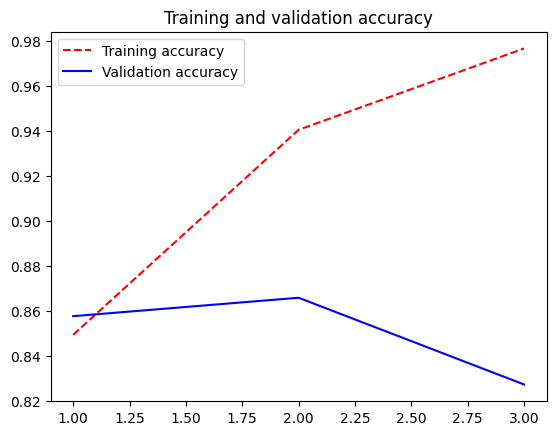

In [ ]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 600, 64)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,983,109 (22.82 MB)

 Trainable params: 1,994,369 (7.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,988,740 (15.22 MB)